Imports

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson


In [50]:
# Read the CSV file into a DataFrame
df = pd.read_csv("AUdata.csv")

# Display the first few rows
df.head()

,ID,AADT,Length,NumLane,LWIDTH,FuncDum,Shoulder,SHType,SHWidth,SHMark,Median,MedWidth,Medmark,TERRDUM,curv,SEAL,SPEED,LowSp,MedSp,HiSp,PerHV,LOSDUM,ROUGH,RUTT,Rain,Sun,THUNDER,WIND,Fatal,Major,Minor,Crash
0,1,15692.50,332,1,3.0,0,0,0,2.1,0,0,5.0,0,0,0.7975,0,20,1,0,0,"6,935",0,0,0,"26,667","2,667",30,0,0,3,0,3
1,2,15692.50,333,1,3.0,0,0,0,2.1,0,0,5.0,0,0,0.3474,0,20,1,0,0,"6,935",0,0,0,"33,333","2,625",30,0,0,3,0,3
2,3,12827.00,200,1,3.2,0,0,0,2.1,0,1,3.5,0,0,0.4595,0,20,1,0,0,8.22,0,0,0,37.5,"2,625",25,0,0,0,0,0
3,4,12986.25,1064,2,3.0,0,0,0,2.1,0,1,0.0,0,1,"1,221",1,60,0,1,0,"5,355",1,60,2.2,30,3,25,0,0,7,1,8
4,5,28713.75,755,3,4.2,0,0,0,3.0,0,1,0.0,0,1,0.6747,1,60,0,1,0,4.66,0,85.5,6.25,60,3,25,0,0,23,6,29


# Data Exploration (Histograms & Correlation Matrix)

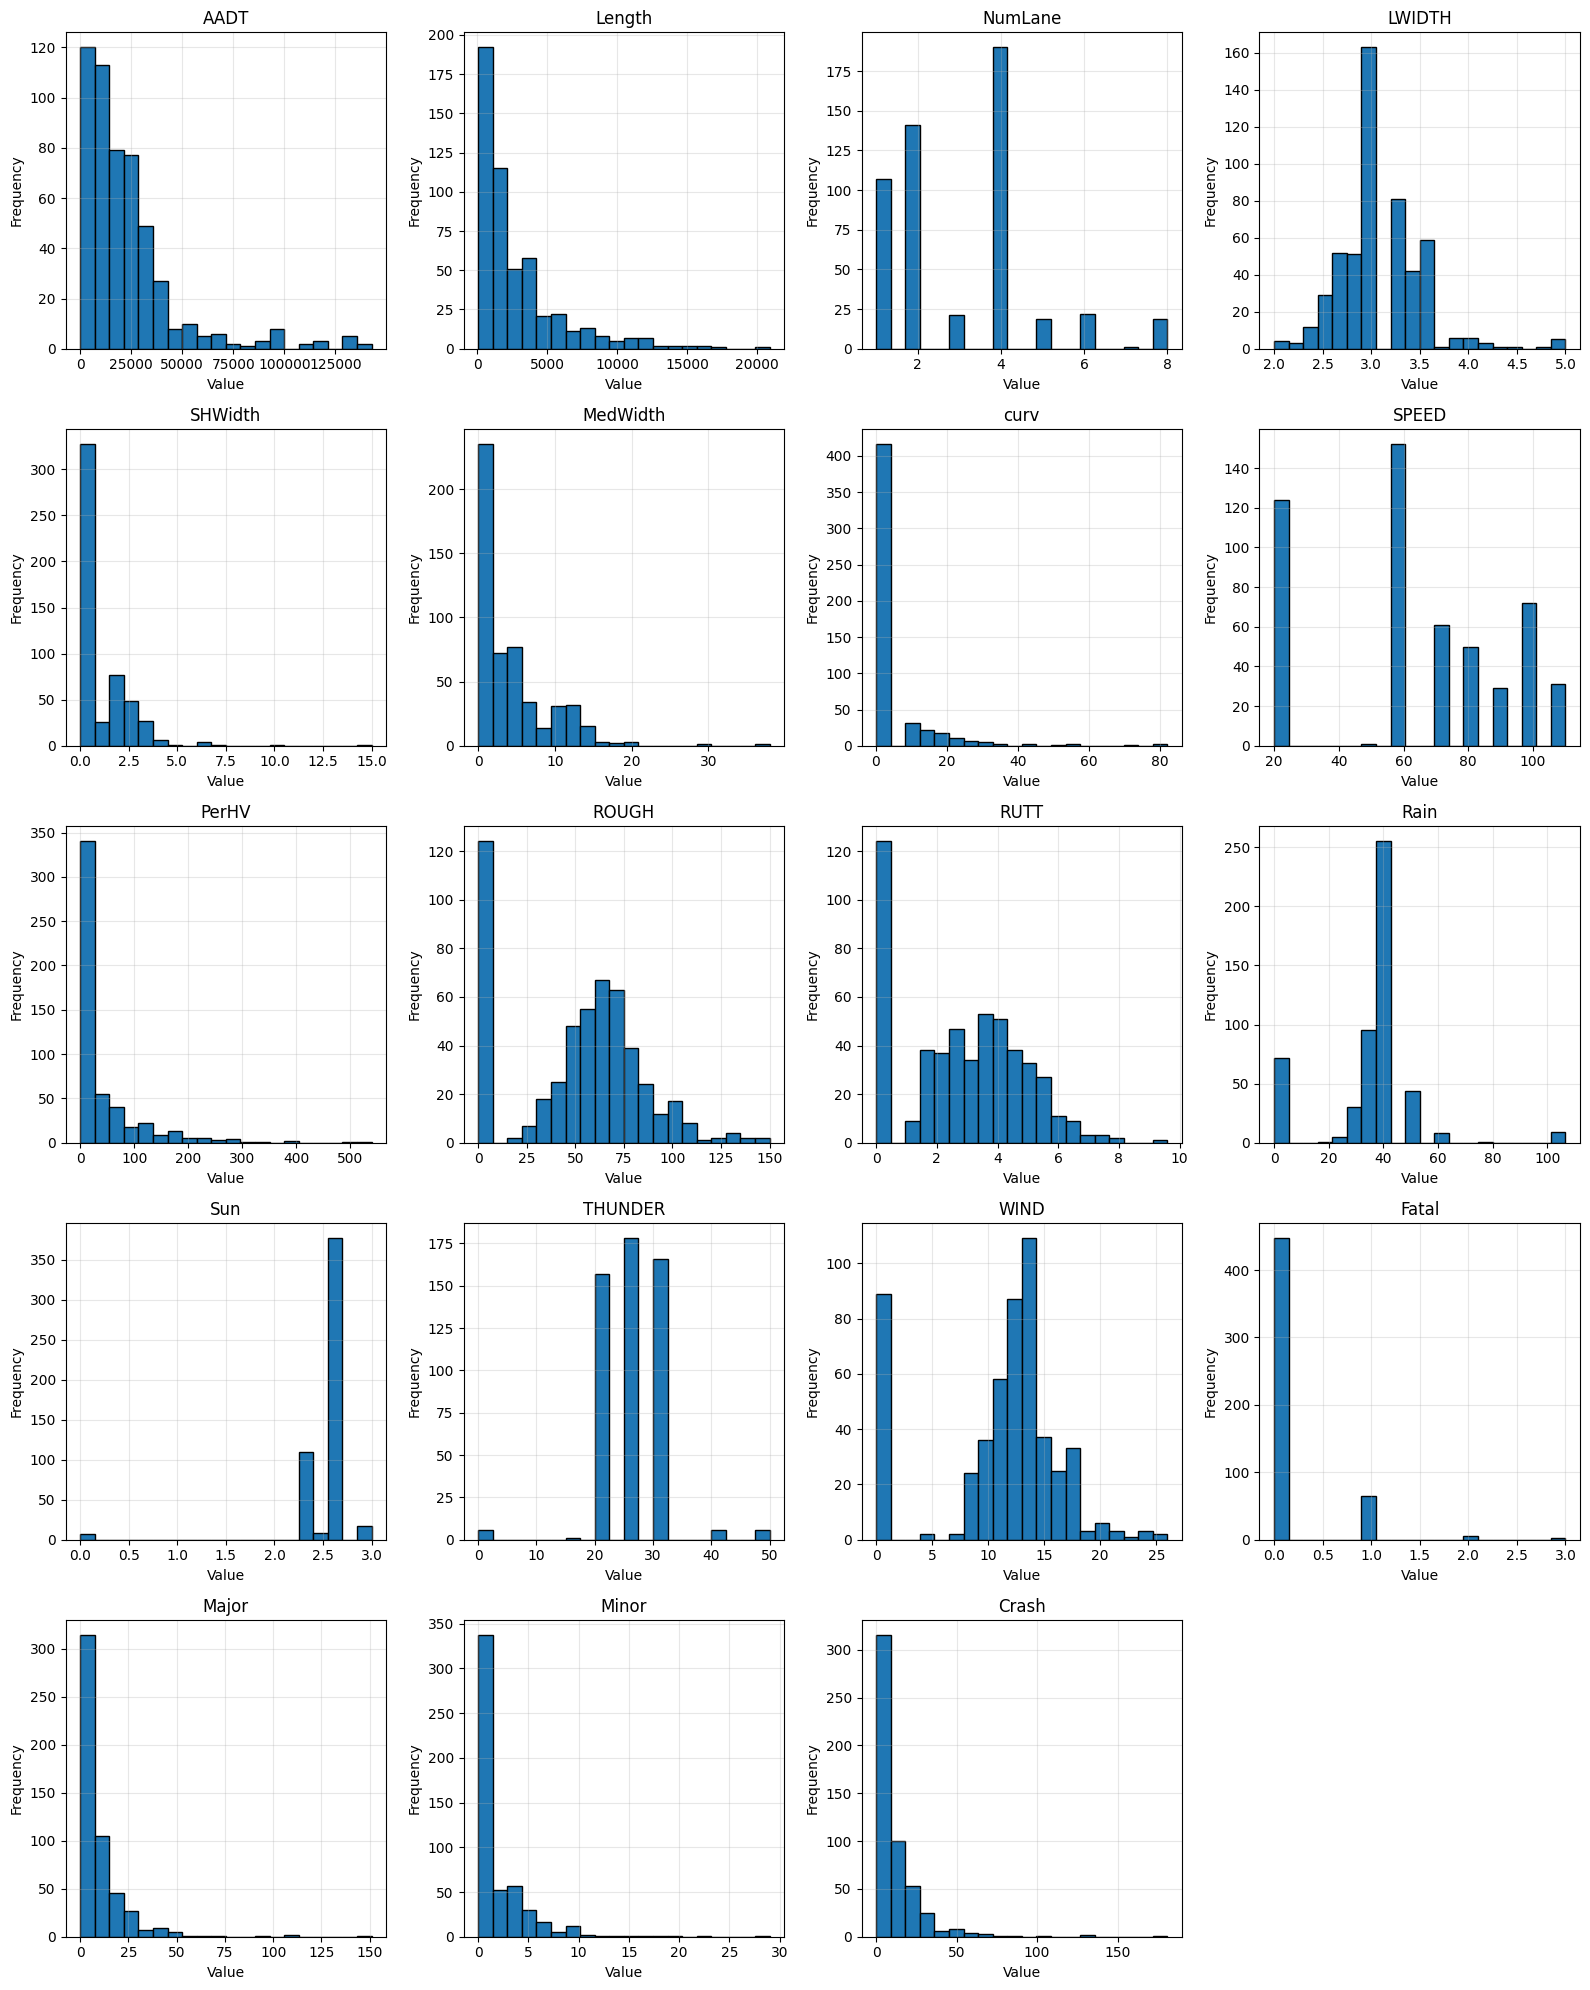

In [51]:
# Exclude ID and convert comma-formatted values to numeric
plot_df = df.drop(columns=["ID"]).apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

# Exclude binary variables containing only 0 and 1
binary_cols = [
    col for col in plot_df.columns
    if set(plot_df[col].dropna().unique()).issubset({0, 1})
]

hist_df = plot_df.drop(columns=binary_cols).select_dtypes(include="number")

# Create histograms
n_cols = 4
n_rows = (len(hist_df.columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, hist_df.columns):
    ax.hist(hist_df[column].dropna(), bins=20, edgecolor="black")
    ax.set_title(column)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)

for ax in axes[len(hist_df.columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

In [52]:
pearson_corr = plot_df.corr(method="pearson")

pearson_corr

,AADT,Length,NumLane,LWIDTH,FuncDum,Shoulder,SHType,SHWidth,SHMark,Median,MedWidth,Medmark,TERRDUM,curv,SEAL,SPEED,LowSp,MedSp,HiSp,PerHV,LOSDUM,ROUGH,RUTT,Rain,Sun,THUNDER,WIND,Fatal,Major,Minor,Crash
AADT,1.000000,-0.181483,0.388345,0.117791,-0.319384,0.102703,-0.011158,-0.026461,-0.023876,-0.309438,0.284558,-0.179176,-0.070116,-0.145025,-0.074708,0.003470,0.071856,-0.177398,0.143820,-0.197921,0.245765,-0.202999,-0.134646,0.030012,0.000285,0.074099,0.052990,0.028478,0.137587,0.107451,0.134323
Length,-0.181483,1.000000,0.009811,-0.144508,0.429349,-0.302031,0.095902,0.226525,-0.025858,0.152412,-0.083212,0.129582,0.041140,0.029238,0.379677,0.440689,-0.380618,0.198285,0.161224,0.276089,-0.067091,0.309610,0.395780,-0.065078,0.026328,0.042114,-0.030744,0.264462,0.310405,0.253420,0.310129
NumLane,0.388345,0.009811,1.000000,0.037965,-0.139965,0.156343,-0.054456,-0.061262,-0.100119,-0.402512,0.295986,-0.219618,-0.014991,-0.058240,0.541042,0.521313,-0.539747,0.198635,0.331403,-0.125166,0.266962,0.315838,0.294523,0.002535,0.029071,0.066055,-0.030742,0.126271,0.324712,0.297886,0.326595
LWIDTH,0.117791,-0.144508,0.037965,1.000000,-0.143238,0.098027,-0.002185,-0.093363,0.110267,0.023893,0.016055,-0.136583,0.090327,0.130938,-0.078718,-0.058878,0.077786,-0.058309,-0.010805,-0.047926,0.103549,-0.038950,-0.094701,0.048727,0.016225,0.195003,-0.151039,-0.108905,-0.027022,-0.027959,-0.030253
FuncDum,-0.319384,0.429349,-0.139965,-0.143238,1.000000,-0.275269,0.063407,0.207724,0.040632,0.243430,-0.012642,0.187983,0.067329,0.059390,0.326262,0.413276,-0.318964,0.110508,0.204403,0.318875,-0.047038,0.347940,0.345830,-0.166653,0.041085,-0.058160,-0.051958,0.077181,-0.222183,-0.219886,-0.222254
Shoulder,0.102703,-0.302031,0.156343,0.098027,-0.275269,1.000000,-0.256355,-0.733856,0.222639,-0.339726,0.048608,-0.112660,-0.009439,0.107807,-0.105527,-0.220864,0.108839,0.047606,-0.175964,-0.129470,-0.078629,-0.073778,-0.184870,0.095749,0.002122,-0.076679,-0.034989,-0.101549,0.057924,0.069842,0.058162
SHType,-0.011158,0.095902,-0.054456,-0.002185,0.063407,-0.256355,1.000000,0.165895,-0.085527,0.072176,0.095148,-0.023004,-0.040710,-0.082405,0.000176,0.030915,-0.001099,-0.035286,0.045109,0.110028,-0.005181,0.007259,0.058718,-0.087192,0.034228,0.051181,0.008612,-0.031262,0.010186,-0.009299,0.005948
SHWidth,-0.026461,0.226525,-0.061262,-0.093363,0.207724,-0.733856,0.165895,1.000000,-0.144102,0.215789,0.035665,0.105670,-0.012185,-0.070037,0.107617,0.216168,-0.110099,-0.058524,0.190910,0.064268,0.109084,0.050771,0.153192,-0.086127,-0.021638,0.048165,0.017605,0.124976,-0.062758,-0.069240,-0.061463
SHMark,-0.023876,-0.025858,-0.100119,0.110267,0.040632,0.222639,-0.085527,-0.144102,1.000000,0.052242,-0.085315,0.120044,0.044361,0.055312,-0.046229,-0.081748,0.056897,0.019222,-0.084934,-0.008312,-0.116120,0.036604,-0.028252,-0.065345,-0.051307,0.029824,0.012708,-0.067681,-0.050939,-0.033882,-0.050103
Median,-0.309438,0.152412,-0.402512,0.023893,0.243430,-0.339726,0.072176,0.215789,0.052242,1.000000,-0.617397,0.376653,0.070353,0.078034,-0.026478,-0.016278,0.031439,0.002220,-0.036472,0.183736,-0.076493,0.100267,0.043566,-0.024771,-0.102664,-0.024053,-0.013180,-0.047284,-0.176787,-0.165354,-0.177847


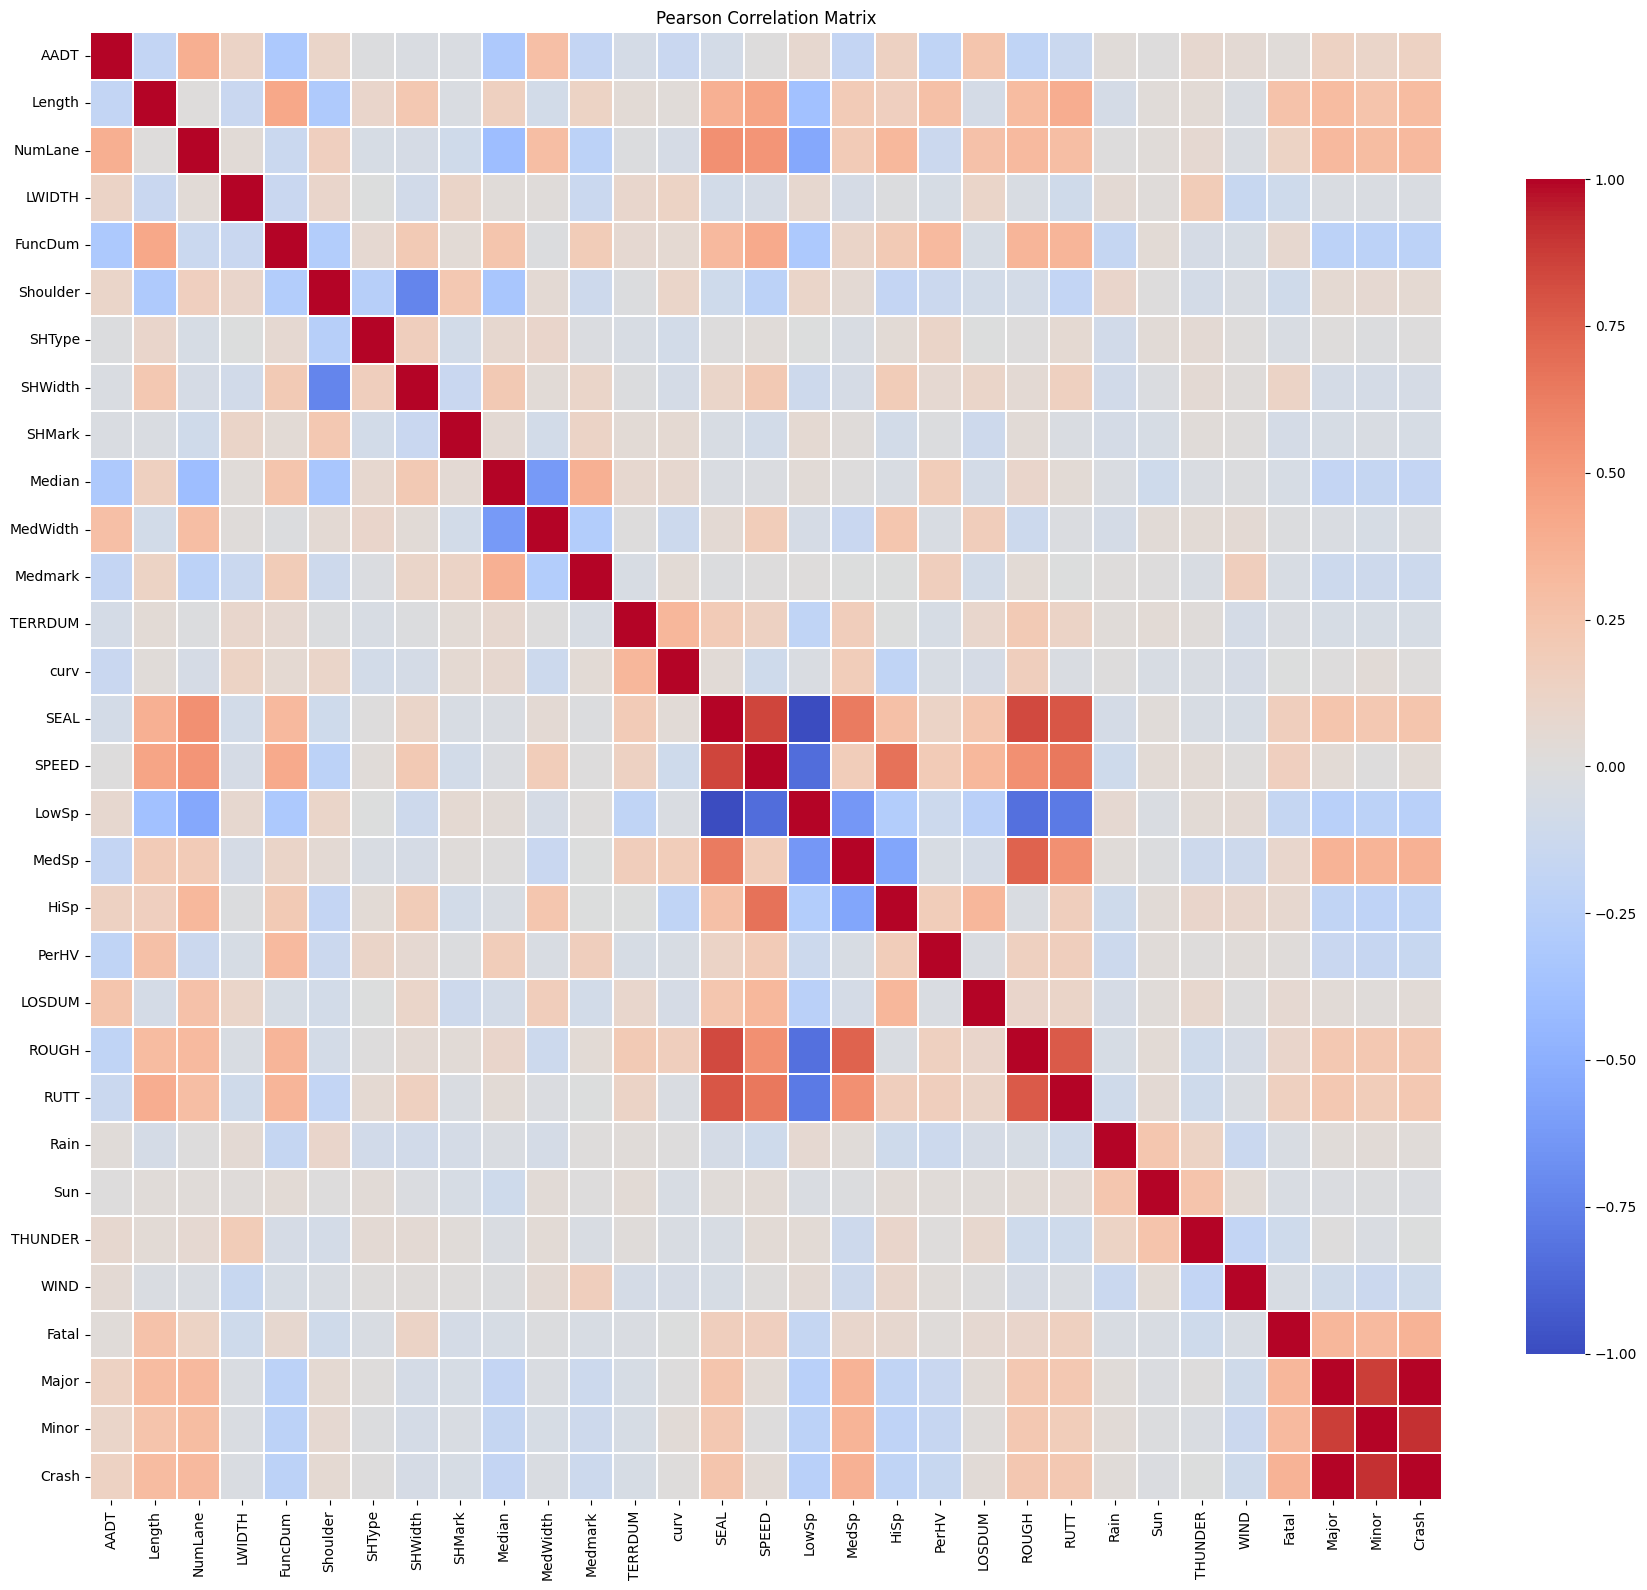

In [53]:
plt.figure(figsize=(18, 16))
sns.heatmap(
    pearson_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=False,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# Safety Perfomance Functions

## Data Cleaning

In [54]:
# Data Cleaning
# Some numerical variables contain commas as decimal separators
decimal_columns = [
    "PerHV",
    "ROUGH",
    "RUTT",
    "Rain",
    "Sun",
    "curv"
]

for col in decimal_columns:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )


# Convert road length from metres to kilometres
df["Length_km"] = df["Length"] / 1000


# Log-transform AADT
df["log_AADT"] = np.log(df["AADT"])

# Setup Variables
# Dependent variable
y = df["Crash"]

# Independent Variables
# EDIT ONLY THIS LIST TO ADD OR REMOVE VARIABLES
predictors = [
    "log_AADT",
    "NumLane",
    "LWIDTH",
    "FuncDum",
    "Shoulder",
    "SHWidth",
    "SHMark",
    "Median",
    "MedWidth",
    "Medmark",
    "TERRDUM",
    "curv",
    "SEAL",
    "SPEED",
    "PerHV",
    "LOSDUM",
    "ROUGH",
    "RUTT",
    "Rain",
    "Sun",
    "THUNDER",
    "WIND"
]
X = df[predictors]

# Add regression intercept
X = sm.add_constant(X)

model_data = pd.concat(
    [y, X, df["Length_km"]],
    axis=1
).dropna()

y_model = model_data["Crash"]

X_model = model_data[
    ["const"] + predictors
]

length_model = model_data["Length_km"]


## Negative Binomial Model

In [55]:
# Negative Binomial Regression Model
nb_model = NegativeBinomial(
    endog=y_model,
    exog=X_model,

    # Length is treated as exposure.
    # statsmodels automatically uses log(Length_km)
    exposure=length_model,

    # NB2: Var(Y) = mu + alpha * mu^2
    loglike_method="nb2"
)

nb_results = nb_model.fit(
    maxiter=500,
    disp=False
)
print("\n==============================")
print("NEGATIVE BINOMIAL MODEL")
print("==============================\n")

# Extract the dispersion parameter (alpha)
alpha = nb_results.params["alpha"]

print("\nEstimated dispersion parameter (alpha):")
print(alpha)

# Print the model results summary
print(nb_results.summary())


# Analyse impact of each variable on the expected number of crashes
coefficients = nb_results.params.drop("alpha")

IRR = np.exp(coefficients)

results_table = pd.DataFrame({
    "Coefficient": coefficients,
    "IRR": IRR,
    "P-value": nb_results.pvalues.drop("alpha")
})

print("\n==============================")
print("COEFFICIENTS AND IRRs")
print("==============================\n")

print(results_table)


# Predict Crashes
df.loc[model_data.index, "Predicted_Crashes_NB"] = nb_results.predict(
    X_model,
    exposure=length_model
)

print("\nFirst predicted values:")
print(
    df[
        ["ID", "Crash", "Predicted_Crashes_NB"]
    ].head(10)
)


NEGATIVE BINOMIAL MODEL


Estimated dispersion parameter (alpha):
0.34852141094002037
                     NegativeBinomial Regression Results                      
Dep. Variable:                  Crash   No. Observations:                  520
Model:               NegativeBinomial   Df Residuals:                      497
Method:                           MLE   Df Model:                           22
Date:                Mon, 14 Sep 2026   Pseudo R-squ.:                  0.1290
Time:                        19:15:45   Log-Likelihood:                -1527.7
converged:                       True   LL-Null:                       -1753.8
Covariance Type:            nonrobust   LLR p-value:                 6.045e-82
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1729      0.628     -1.868      0.062      -2.404       0.058
log_AADT       0.3410      0.046      7.463 

## Poisson Model

In [56]:
# Poisson Regression Model

poisson_model = Poisson(
    endog=y_model,
    exog=X_model,
    # Length is treated as exposure (statsmodels auto-logs this)
    exposure=length_model
)

poisson_results = poisson_model.fit(
    maxiter=500,
    disp=False
)

print("\n==============================")
print("POISSON MODEL RESULTS")
print("==============================\n")

# Print the model summary
print(poisson_results.summary())


# Analyse impact of each variable on the expected number of crashes

coefficients = poisson_results.params
IRR = np.exp(coefficients)

results_table = pd.DataFrame({
    "Coefficient": coefficients,
    "IRR": IRR,
    "P-value": poisson_results.pvalues
})

print("\n==============================")
print("COEFFICIENTS AND IRRs (POISSON)")
print("==============================\n")

print(results_table)


# Predict Crashes

df.loc[model_data.index, "Predicted_Crashes_Poisson"] = poisson_results.predict(
    X_model,
    exposure=length_model
)

print("\nPredicted crashes (Poisson):")
print(
    df[
        ["ID", "Crash", "Predicted_Crashes_Poisson"]
    ].head(10)
)


POISSON MODEL RESULTS

                          Poisson Regression Results                          
Dep. Variable:                  Crash   No. Observations:                  520
Model:                        Poisson   Df Residuals:                      497
Method:                           MLE   Df Model:                           22
Date:                Mon, 14 Sep 2026   Pseudo R-squ.:                  0.5748
Time:                        19:15:45   Log-Likelihood:                -2020.4
converged:                       True   LL-Null:                       -4751.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0967      0.297     -3.690      0.000      -1.679      -0.514
log_AADT       0.3117      0.024     12.932      0.000       0.264       0.359
NumLane        0.1063      0

# Empirical Bayes Method

In [57]:
# Define the testroad characteristics --> same variables as used for training (binomial filtered out, AADT log-transformed, length in km)

test_road = pd.DataFrame(
    [
        {
            "log_AADT": np.log(41000),
            "NumLane": 3,
            "LWIDTH": 3.5,
            "FuncDum": 0,
            "Shoulder": 1,
            "SHWidth": 0,
            "SHMark": 0,
            "Median": 0,
            "MedWidth": 13,
            "Medmark": 0,
            "TERRDUM": 0,
            "curv": 0.6137,
            "SEAL": 1,
            "SPEED": 80,
            "PerHV": 6.5,
            "LOSDUM": 0,
            "ROUGH": 70,
            "RUTT": 5,
            "Rain": 30,
            "Sun": 2,
            "THUNDER": 20,
            "WIND": 15,
        }
    ]
)

# Add a constant to the test road data for the intercept
test_road_with_const = sm.add_constant(test_road, has_constant="add")

In [58]:
print(nb_results.params)

const      -1.172872
log_AADT    0.340996
NumLane     0.126838
LWIDTH      0.084797
FuncDum    -0.633702
Shoulder    0.147271
SHWidth    -0.040183
SHMark     -0.063476
Median      0.101657
MedWidth   -0.009396
Medmark    -0.122313
TERRDUM     0.026879
curv        0.000667
SEAL        0.656521
SPEED      -0.027260
PerHV      -0.001975
LOSDUM      0.278018
ROUGH       0.006053
RUTT       -0.010781
Rain       -0.002634
Sun         0.106565
THUNDER    -0.006035
WIND       -0.009567
alpha       0.348521
dtype: float64


In [61]:
print(test_road_with_const)

   const   log_AADT  NumLane  LWIDTH  FuncDum  Shoulder  SHWidth  SHMark  Median  MedWidth  Medmark  TERRDUM    curv  SEAL  SPEED  PerHV  LOSDUM  ROUGH  RUTT  Rain  Sun  THUNDER  WIND
0    1.0  10.621327        3     3.5        0         1        0       0       0        13        0        0  0.6137     1     80    6.5       0     70     5    30    2       20    15


In [62]:
# Apply the SPF from the NB model to the test road

pred_annual = nb_results.predict(test_road_with_const)[0]
n_pred_2yr = pred_annual * 2

print(f"2-Year Predicted Crashes: {n_pred_2yr:.2f}")

2-Year Predicted Crashes: 12.78


In [63]:
# Weight determination based on the predicted number of crashes and the dispersion parameter

# Observations and Dispersion Parameter
alpha = 0.348521
obs_fatal, obs_major, obs_minor = 5, 35, 10
obs_total_2yr = obs_fatal + obs_major + obs_minor

# Weight calculation
weight = 1 / (1 + alpha * n_pred_2yr)
print (f"Weight for the test road: {weight:.4f}")

Weight for the test road: 0.1834


In [65]:
# Expected total crashes over 2 years
n_expected_2yr = (weight * n_pred_2yr) + ((1 - weight) * obs_total_2yr)
print(f"Expected total crashes over 2 years: {n_expected_2yr:.2f}")

Expected total crashes over 2 years: 43.17


In [69]:
# Factor in severoity distribution based on observed crash data
n_expected_2yr = n_expected_2yr
exp_fatal = n_expected_2yr * (obs_fatal / obs_total_2yr)
exp_major = n_expected_2yr * (obs_major / obs_total_2yr)
exp_minor = n_expected_2yr * (obs_minor / obs_total_2yr)

In [70]:
# Print the summary of predicted crashes based on the EBM
print(f"2-Year SPF Predicted Crashes: {n_pred_2yr:.2f}")
print(f"EB Weight Factor (w): {weight:.4f}")
print(f"2-Year Expected Total Crashes: {n_expected_2yr:.2f}")
print(f"  - Fatal: {exp_fatal:.2f} crashes/year")
print(f"  - Major: {exp_major:.2f} crashes/year")
print(f"  - Minor: {exp_minor:.2f} crashes/year")


2-Year SPF Predicted Crashes: 12.78
EB Weight Factor (w): 0.1834
2-Year Expected Total Crashes: 43.17
  - Fatal: 4.32 crashes/year
  - Major: 30.22 crashes/year
  - Minor: 8.63 crashes/year
